# California Housing Prices
## Data Source
This dataset is used in [Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow, 3rd Edition](https://learning.oreilly.com/library/view/hands-on-machine-learning/9781098125967/) by Aurélien Géron.  
The description of the dataset can be found [here](https://github.com/ageron/data/tree/main/housing)
## Goal
Apply several feature engineering measures to the raw dataset and build a ML model that takes in the engineered featrues to predict house prices
## Structue
1. Load Data
2. Perform Preliminary EDA
3. Create the Test Set
4. Perform In-depth EDA on Train Set
5. Prepare Data
6. Pipeline Comparison

**Note**: _The notebook basically follows [Mr. Géron's notebook for the book's demostration](https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb), with some additional steps that I deemeed helpful for exploring ScikitLearn and improving the model's performance._


In [1]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import shutil

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
## Download data
**Note**: You mind need to close VPN if you have one

In [2]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        with urllib.request.urlopen(url) as response:
            shutil.copyfileobj(response, tarball_path.open("wb"))
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# 2. Perform Preliminary EDA
This step is pure metadata inspection (e.g., column names, data types, obvious impossible values, missing value patterns)

In [ ]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


1. `total_bedrooms` has 207 missing values

### Numeric Columns

In [4]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


1. According to [the Wikepdia page for California](https://en.wikipedia.org/wiki/California), the range of longitude and latitude of California is:
     - Latitude: 32°32′ N to 42° N
     - Longitude: 114°8′ W to 124°26′ W  
    -> Somehow the min value of longtitude is to the west of the west bound, but given it's not a severe off, we let it be.


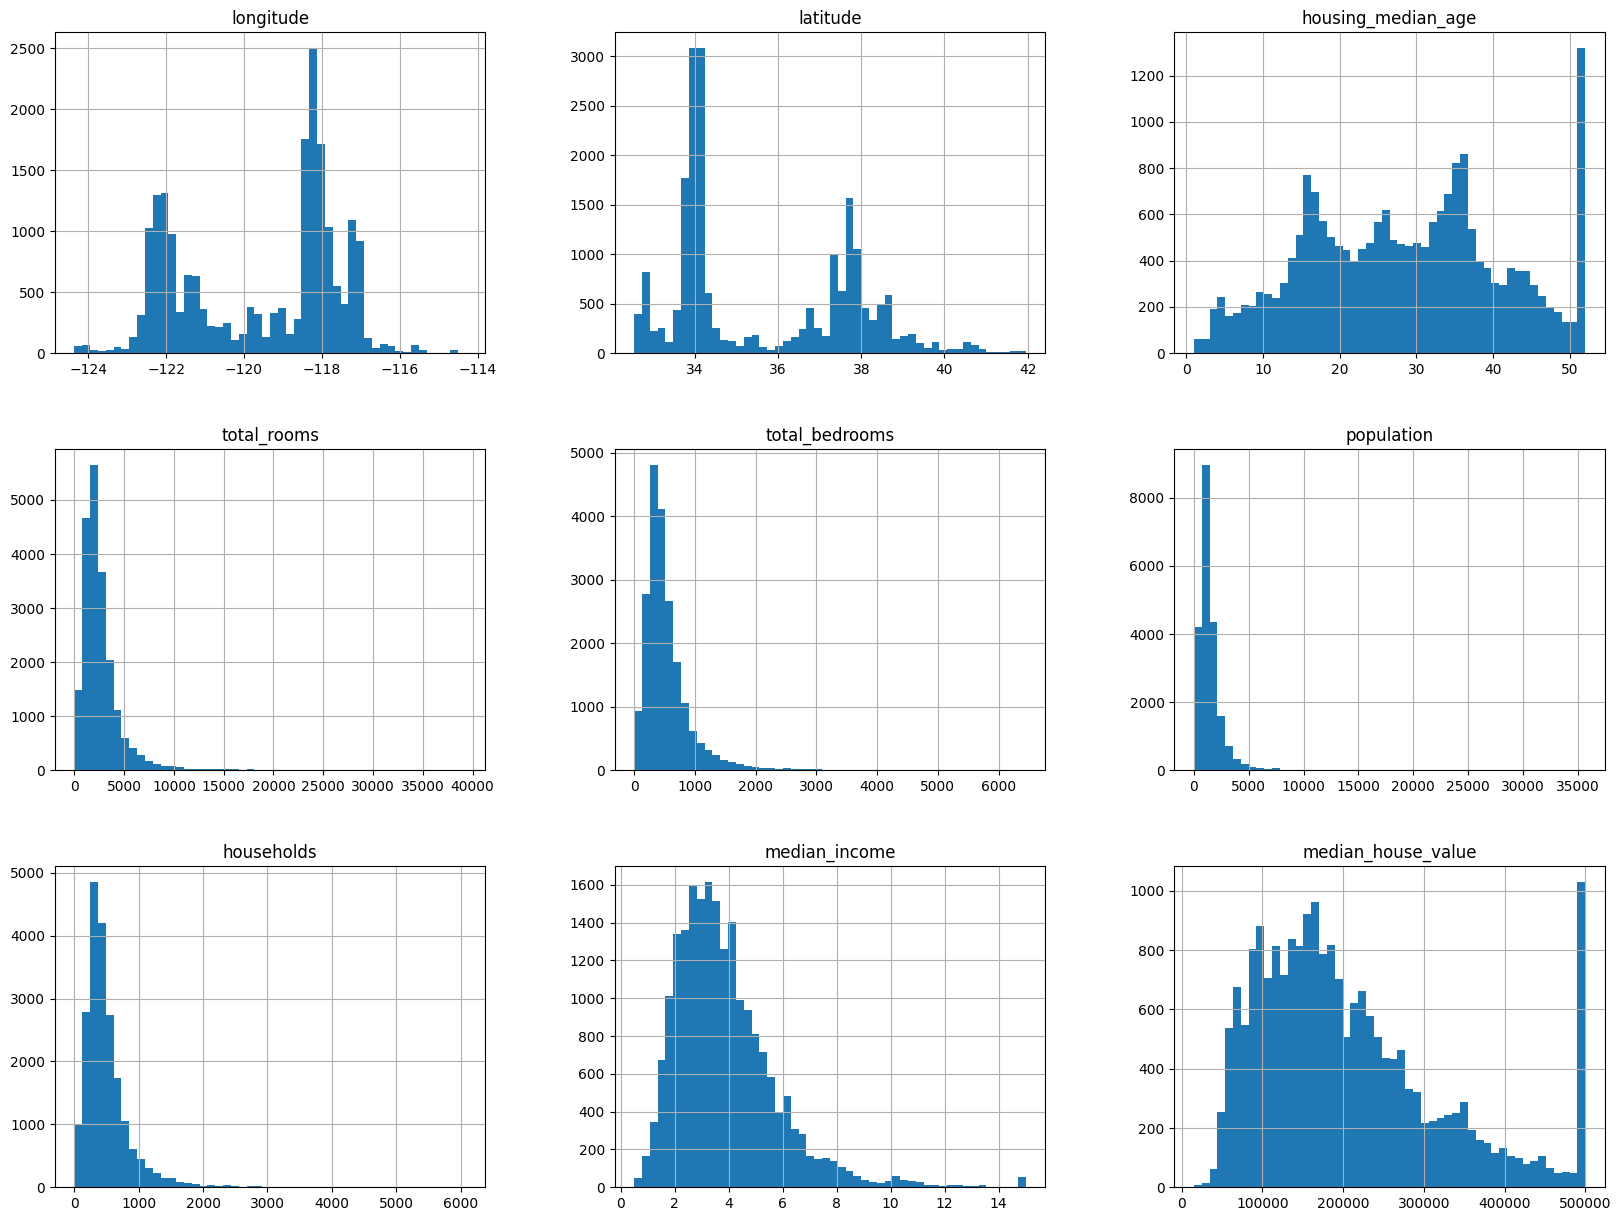

In [5]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

1. The histgrams of `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, and `median_house_value` all show a right-skewed distrubtion. (`median_house_value` has the values capped at 500001, otherwise we can also observe such skew). 
2. Usually non-negative variables that are of aggregated counts behave this way.
3. For these distrubtions, it's typicallly appropriate to log-transform them before feeding them to the model. Because doing so we can reduce skewness through compressing extreme values and thus make the relationships more linear/stable.

### Non-numeric Columns

In [6]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

It seems only a few blocks are categorized as `ISLAND`. This might suggest that model would struggle to learnt the pattern for this category. We can perform some transformation to merge this categories with others if deemed necessary.

# 3. Create the Test Set

To avoid inbalance of the label between the train and test sets, we bin the median income into income category and stratefy based on it (but we don't use income category as a feature)

In [7]:
from sklearn.model_selection import train_test_split

housing["income_cat"] = pd.cut(housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)


train_set, test_set = train_test_split(
    housing, 
    test_size=0.2, 
    stratify=housing["income_cat"],
    random_state=42
)

# drop income_cat after splitting
for set in (train_set, test_set):
    set.drop("income_cat", axis=1, inplace=True)

# have a quick view on the split
train_set.shape, test_set.shape

((16512, 10), (4128, 10))

In [8]:
# replace housing with the train set
housing = train_set.copy()

# 4. Perform In-depth EDA on the Train Set

## Visualize Geo data

In [9]:
# Download the California image
IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)
filename = "california.png"
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)

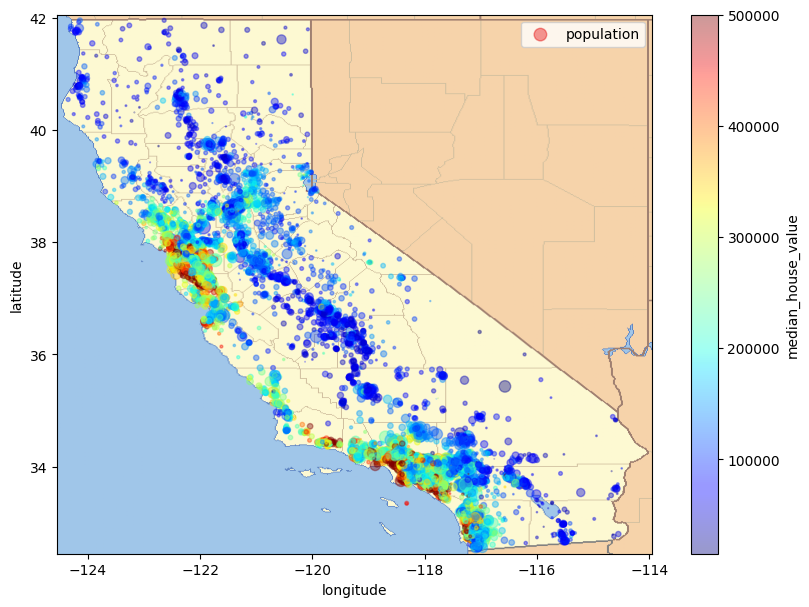

In [10]:
# plot the housing data on the California map with population as the size of the circle and median house value as the color
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
    s=housing["population"] / 100, label="population", figsize=(10, 7),
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.legend()
plt.show()


1. We can clearly see that the major cities (San Francisco, Santa Babara, Los Angeles, and San Diego) have clustered blocks, higher median house values, and higher population.
2. On the other hand, the Central Valley area has quite concentrated population but relatively lower median house value (apart from Sacramento)
3. Lake Tahoe has a small cluster of mid housing price — becuase it's a premier year-round resort destination (winter skiing and summer water activities)
4. Generally speaking, the housing price is higher when getting closer the Pacific ocean

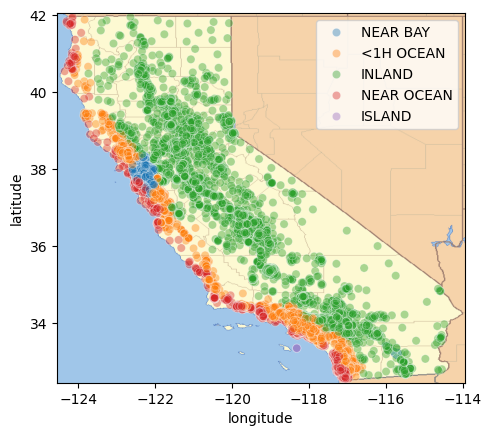

In [11]:
# check ocean proximity on the map

sns.scatterplot(data=housing, x="longitude", y="latitude", hue="ocean_proximity", 
alpha=0.4)
california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.legend()
plt.show()

1. Only the San Francisco Bay Area has the `NEAR BAY` category
2. The `ISLAND` category only appears on Santa Catalina but not other Channel Islands (could be a result of aggregation)

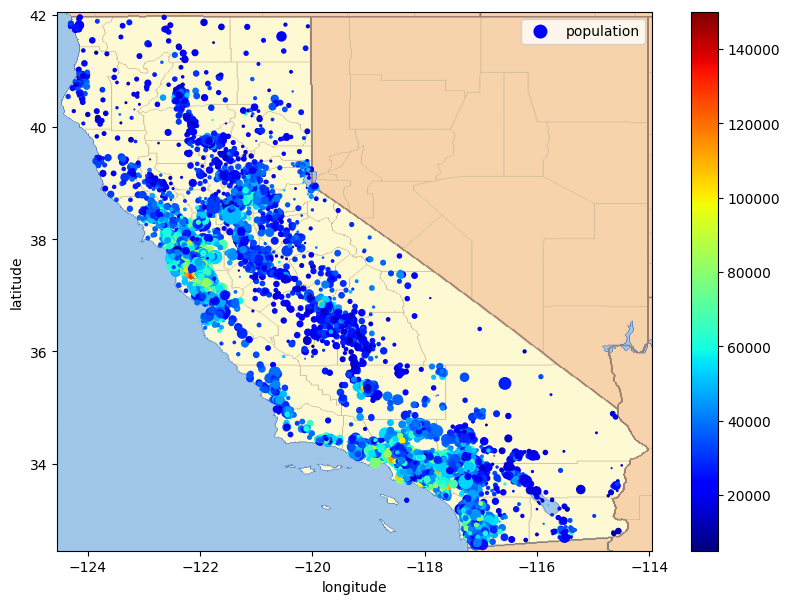

In [12]:
# see how median income is distributed on the map
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=1,
    s=housing["population"] / 100, label="population", figsize=(10, 7),
    c=housing["median_income"] * 10000, cmap=plt.get_cmap("jet"), colorbar=True,
)

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.legend()
plt.show()

It seems the geo distribution of the median income is similar to the one of the housing price

## Visualize correlations

In [13]:
# see the correlation between the features and the target
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

1. The `median_income` is the most correlated feature with the median house value
2. The `total_rooms`, `housing_median_age`, and `households` are also positively correlated with the median house value, but the correlation is wewak
3. The `total_bedrooms`, `population`, and `longitude` are negatively correlated with the median house value, but, again, the correlation is weak

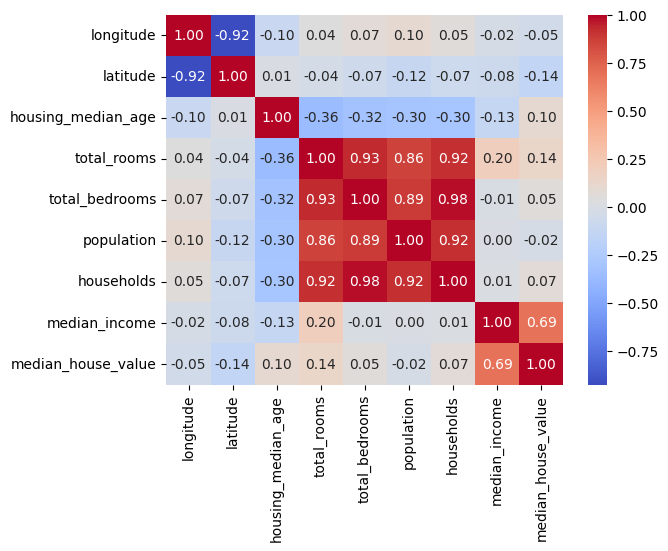

In [14]:
# visualize the correlation matrix
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

1. `total_rooms`, `total_bedrooms`, `populaiton`, and `households` have strong postivie linear correlation with each other, which would usually lead to multicollinearity issue if we use a unregularized linear model. Why? because having multiple features that are can be predicted by one another would introduce instability in coefficients — small data changes can cause major swings in coefficient values. So, we usually need to introducing regularization (i.e. forcing the model to generalize by adding penalty terms to the loss function)
    - Below I will do a experiment on various pipelines to show-case this
2. `longitude` and `latitude` has a strong negative correlation because California basically goes from NW to SE
3. `total_rooms`, `total_bedrooms`, `populaiton`, and `households` have a medium negative correlation with `housing_median_age`

# 5. Prepare Data

This section demostrates the data preparation methods that we intend to explore and apply modifying the `train_set` and `test_set` directly

## Imputation

In [15]:
# impute missing values in `total_bedrooms`
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.drop("ocean_proximity", axis=1)
imputer.fit(housing_num)
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [16]:
# see the imputed values
for feature, stats in zip(imputer.feature_names_in_, imputer.statistics_):
    print(f"{feature}: {stats}")

longitude: -118.51
latitude: 34.26
housing_median_age: 29.0
total_rooms: 2125.0
total_bedrooms: 434.0
population: 1167.0
households: 408.0
median_income: 3.5385
median_house_value: 179200.0


In [17]:
# see the strategy used to impute missing values
imputer.strategy

'median'

## VIF Diagnostic
We'd need to check the Variance Inflation Factor (VIF) to understand the degree of multicollinearity. The formula of VIF goes:
> 1 / (1- R**2)

With R**2 being higher (the square of Pearson correlation coefficient), the VIF value would also be higher. Typically,
- When VIF > 5 signifies noticeable multicollineariy
- Wenn VIF > 10 signifies severe multicollinearity; measures need to taken

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def compute_vif(df_num: pd.DataFrame) -> pd.DataFrame:
    cleaned_df = df_num.dropna().copy()

    # drop the target variable
    cleaned_df = cleaned_df.drop(columns=["median_house_value"])

    # add a constant column to the dataframe
    cleaned_df = add_constant(cleaned_df)

    # calculate VIF for each feature
    vif = pd.DataFrame()
    vif["feature"] = cleaned_df.columns
    vif["vif"] = [variance_inflation_factor(cleaned_df.values, i) for i in range(len(cleaned_df.columns))]

    # drop the constant row
    vif = vif[vif["feature"] != "const"]

    return vif.sort_values(by="vif", ascending=False)

vif_df = compute_vif(housing_num)
vif_df

,feature,vif
5,total_bedrooms,35.415771
7,households,34.872018
4,total_rooms,12.648702
2,latitude,8.805011
1,longitude,8.672768
6,population,7.165909
8,median_income,1.726236
3,housing_median_age,1.265221


1. `total_bedrooms`, `households` (~35): very strong collinearity
2. `total_rooms` (~12.6): high collinearity
3. `latitude`, `longitude`, `population` (~7-9): moderate-to-high
4. `median_income`, `housing_median_age` (~1-2): low

In [19]:
# one way to avoid the collinearity is to calculate ratios of variables that are highly correlated with each other
housing_num["rooms_per_household"] = housing_num["total_rooms"] / housing_num["households"]
housing_num["bedrooms_per_room"] = housing_num["total_bedrooms"] / housing_num["total_rooms"]
housing_num["population_per_household"] = housing_num["population"] / housing_num["households"]

In [20]:
vif_df = compute_vif(housing_num)
vif_df

,feature,vif
5,total_bedrooms,48.070331
7,households,43.531539
4,total_rooms,18.468262
2,latitude,9.359428
1,longitude,9.049430
6,population,8.059710
10,bedrooms_per_room,2.773938
8,median_income,2.118273
9,rooms_per_household,1.642938
3,housing_median_age,1.266315


## Categorical Features

In [21]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = housing[["ocean_proximity"]]
cat_encoder = OneHotEncoder()
housing_cat_encoded = cat_encoder.fit_transform(housing_cat)
housing_cat_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

A sparse matrix metric saves memory and increases calculation speed. If you want to have a dense array, you can call the `toarray()` method

In [22]:
housing_cat_encoded.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [23]:
# see the categories
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

## Cluster-based locations

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans

class LocationClusterer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
        
    def fit(self, X, y=None):
        # X is expected as DataFrame with columns: longitude and latitude
        self.kmeans.fit(X[["longitude", "latitude"]])
        return self
    
    def transform(self, X):
        return self.kmeans.predict(X[["longitude", "latitude"]]).reshape(-1, 1)


In [25]:
cluster_simil = LocationClusterer(n_clusters=10, random_state=42)
similarity_matrix = cluster_simil.fit_transform(housing_num[["longitude", "latitude"]])
similarity_matrix

array([[7],
       [1],
       [7],
       ...,
       [3],
       [1],
       [7]], shape=(16512, 1), dtype=int32)

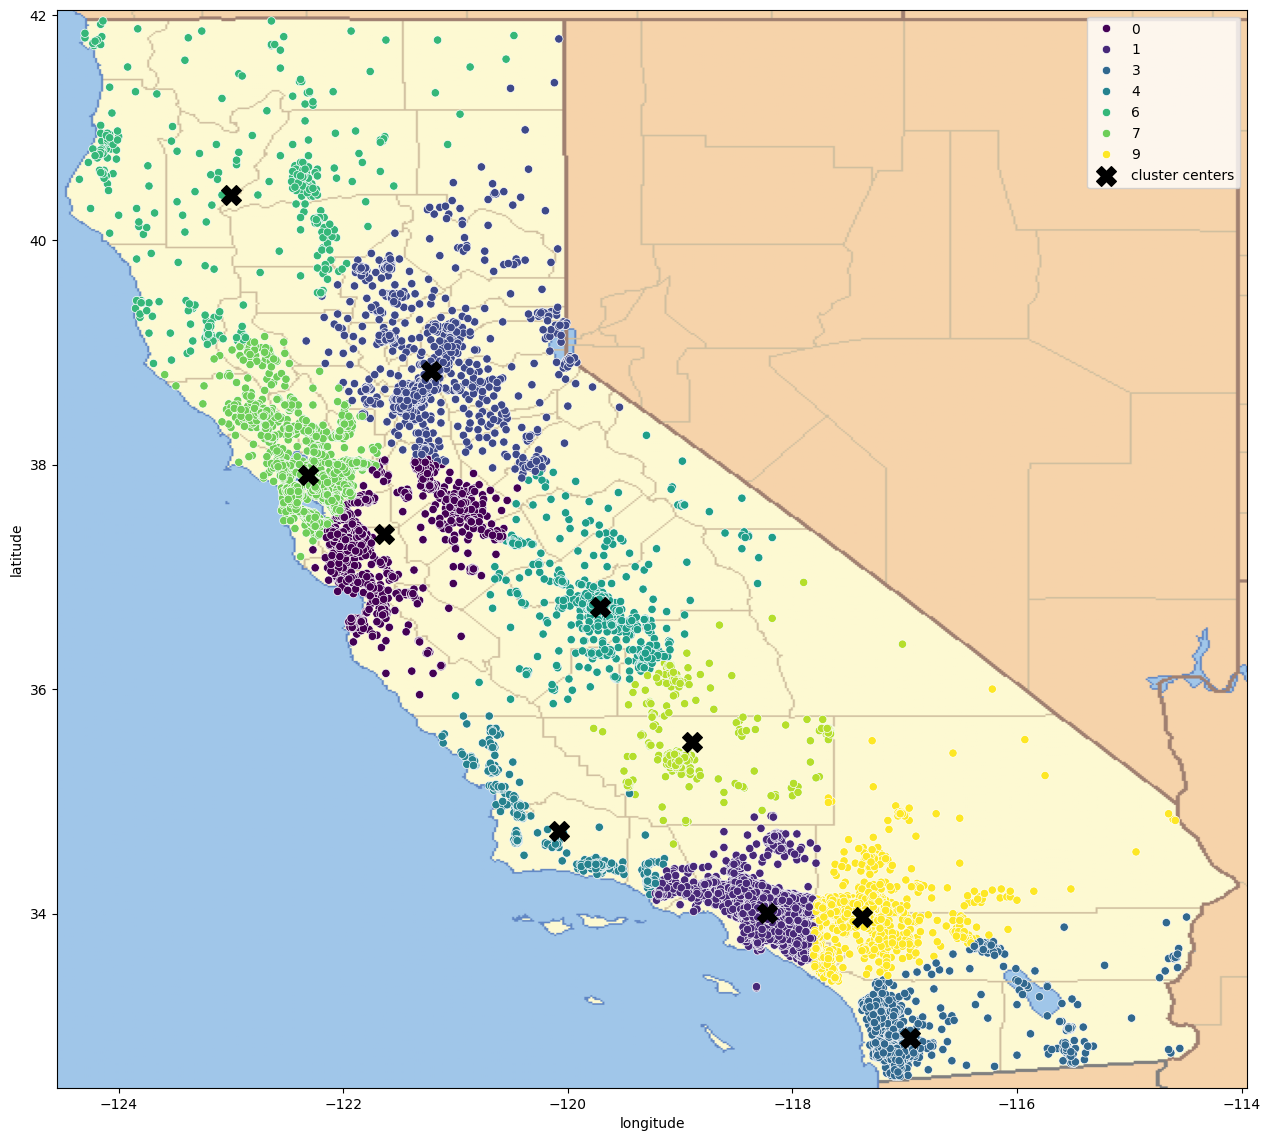

In [26]:
# plot the clusters on the map
plt.figure(figsize=(20, 14))
sns.scatterplot(data=housing_num, x="longitude", y="latitude", hue=similarity_matrix.flatten(), palette="viridis")

# plot the cluster centers
plt.scatter(cluster_simil.kmeans.cluster_centers_[:, 0], cluster_simil.kmeans.cluster_centers_[:, 1],
            marker="X", s=200, color="black", label="cluster centers")

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.legend()
plt.show()


## Standardization of numeric values

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
housing_num_scaled = scaler.fit_transform(housing_num)
housing_num_scaled


array([[-1.42303652,  1.0136059 ,  1.86111875, ..., -0.86602737,
         2.14135179, -0.33020372],
       [ 0.59639445, -0.702103  ,  0.90762971, ...,  0.0245495 ,
        -0.56854491, -0.25361631],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.04119332,
        -0.21643202, -0.05104091],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ..., -0.10998748,
        -0.26285278,  0.15854151],
       [ 0.58639727, -0.73960483,  0.66925745, ..., -0.36093745,
         0.3151675 , -0.21033248],
       [-1.41803793,  0.94797769,  1.22545939, ..., -1.32397227,
         4.1738051 ,  0.04958379]], shape=(16512, 12))

# 6. Pipeline Comparison: Why Multicollinearity Matters
In this section, I compare:
1) OLS Linear Regression
    - With Raw Input
    - With Calculated Ratios
2) Regularized Linear Regression (RidgeCV)
3) Tree-Based Model (RandomForestRegressor)
using the same preprocessing and the same train/test split.


In [28]:
# split the train and test sets into X and y
X_train = train_set.drop("median_house_value", axis=1).copy()
y_train = train_set["median_house_value"].copy()
X_test = test_set.drop("median_house_value", axis=1).copy()
y_test = test_set["median_house_value"].copy()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(16512, 9) (16512,) (4128, 9) (4128,)


## Build one shared preprocessor pipline

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# define the feature columns by their data types
location_features = ["longitude", "latitude"]
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_features = [col for col in num_features if col not in location_features]
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

location_cluster_pipeline = Pipeline([
    ("cluster", LocationClusterer(n_clusters=10, random_state=42)),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features),
    ("location", location_cluster_pipeline, location_features),
])


## Define the pipelines

In [30]:
from sklearn.linear_model import LinearRegression

# OLS Linear Regression with raw input
linreg_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [31]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ["ratio"]

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler())

def drop_features(X):
    return X[:, [0]]

def drop_name(function_transformer, feature_names_in):
    return ["ratio"]

# OLS Linear Regression with calculated ratios

preprocessor_ratio = ColumnTransformer(
    [
        ("bedroom_per_room", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
        ("rooms_per_household", ratio_pipeline(), ["total_rooms", "households"]),
        ("population_per_household", ratio_pipeline(), ["population", "households"]),
        ("drop_ratio_raw_cols", "drop", ["total_bedrooms", "total_rooms", "households"]),
        ("num", numeric_pipeline, [col for col in num_features if col not in ["total_bedrooms", "total_rooms", "households", "population"]+location_features]),
        ("cat", categorical_pipeline, cat_features),
        ("location", location_cluster_pipeline, location_features),
    ],
)
linreg_pipeline_ratio = Pipeline(
    [
        ("preprocessor", preprocessor_ratio),
        ("model", LinearRegression())
    ]
)

In [32]:
# RidgeCV
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

In [33]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, random_state=42))
    ]
)

In [34]:
models = {
    "linreg": linreg_pipeline,
    "linreg_ratio": linreg_pipeline_ratio,
    "ridge": ridge_pipeline,
    "rf": rf_pipeline
}

## Train and Compare

In [35]:
from sklearn.metrics import mean_squared_error, r2_score

rows = []
fitted_models = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    rows.append({
        "model": model_name,
        "train_rmse": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_rmse": np.sqrt(mean_squared_error(y_test, test_pred)),
        "train_r2": r2_score(y_train, train_pred),
        "test_r2": r2_score(y_test, test_pred)
    })

results_df = pd.DataFrame(rows)
results_df
    
    

Training linreg...
Training linreg_ratio...
Training ridge...
Training rf...


,model,train_rmse,test_rmse,train_r2,test_r2
0,linreg,67270.964535,70457.864916,0.659657,0.629141
1,linreg_ratio,70567.288435,72237.380125,0.625485,0.610171
2,ridge,67275.636727,70382.028000,0.659609,0.629938
3,rf,21539.109010,59371.132412,0.965109,0.736670


## Random Search CV

In [36]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

param_distributions = {
    "linreg": {
        "model__fit_intercept": [True, False],
        "model__positive": [False, True],
    },
    "linreg_ratio": {
        "model__fit_intercept": [True, False],
        "model__positive": [False, True],
    },
    "ridge": {
        "model__alpha": loguniform(1e-4, 1e3),
        "model__fit_intercept": [True, False],
        "model__solver": ["auto", "lbfgs", "sag", "sparse_cg"],
    },
    "rf": {
        "model__n_estimators": randint(200, 1000),
        "model__max_depth": [None, 8, 12, 16, 24, 32],
        "model__min_samples_split": randint(2, 20),
        "model__min_samples_leaf": randint(1, 10),
        "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
        "model__bootstrap": [True, False],
    },
}

n_iter_map = {
    "linreg": 8,
    "linreg_ratio": 4,
    "ridge": 30,
    "rf": 50,
}
search_results = []
best_estimators = {}
for name, pipe in models.items():
    print(f"Running random search for: {name}")
    rs = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=n_iter_map[name],
        scoring="neg_root_mean_squared_error",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        refit=True,
    )
    rs.fit(X_train, y_train)
    best_estimators[name] = rs.best_estimator_
    # Evaluate on holdout test set
    y_pred_test = rs.best_estimator_.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)
    search_results.append({
        "model": name,
        "best_cv_rmse": -rs.best_score_,  # convert from negative
        "test_rmse": test_rmse,
        "test_r2": test_r2,
        "best_params": rs.best_params_,
    })
results_search_df = pd.DataFrame(search_results).sort_values("test_rmse")
results_search_df

Running random search for: linreg
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/Users/linhenry/projects/side_projects/california_housing_price/.venv/lib/python3.14/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Running random search for: linreg_ratio
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Running random search for: ridge
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/linhenry/projects/side_projects/california_housing_price/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/linhenry/projects/side_projects/california_housing_price/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/linhenry/projects/side_projects/california_housing_price/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/linhenry/projects/side_projects/california_housing_price/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/linhenry/projects/side_projects/california_housing_price/

Running random search for: rf
Fitting 5 folds for each of 50 candidates, totalling 250 fits


/Users/linhenry/projects/side_projects/california_housing_price/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,model,best_cv_rmse,test_rmse,test_r2,best_params
3,rf,57816.177806,58126.012583,0.747599,"{'model__bootstrap': True, 'model__max_depth':..."
2,ridge,67362.156601,70455.336468,0.629167,"{'model__alpha': 0.002498713568466946, 'model_..."
0,linreg,67362.249635,70457.864916,0.629141,"{'model__positive': False, 'model__fit_interce..."
1,linreg_ratio,70783.446938,71308.165531,0.620135,"{'model__positive': True, 'model__fit_intercep..."
